# Who Is Hiring: 15 Years of Hacker News Job Postings

Every month since April 2011, Hacker News has hosted an "Ask HN: Who is hiring?"
thread where companies post openings. This notebook analyzes 93,122 postings
across 183 monthly threads, April 2011 to September 2026.

Data collection and parsing are in `src/`. This notebook only reads the
processed postings table.

In [34]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import StrMethodFormatter

PROJECT_ROOT = Path("..")
POSTINGS_PATH = PROJECT_ROOT / "data" / "processed" / "postings.parquet"
FIGURES_DIRECTORY = PROJECT_ROOT / "figures"
FIGURES_DIRECTORY.mkdir(exist_ok=True)

# Reset any style injected by the editor theme, then pin our own.
# Every figure gets a white background so saved PNGs look the same
# on GitHub regardless of a viewer's light or dark mode.
plt.style.use("default")

plt.rcParams.update({
    "figure.figsize": (11, 5.5),
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "font.size": 10,
    "axes.grid.axis": "y",
})

# Shared palette so every chart in the notebook matches.
MONTHLY_COLOR = "#a9bcd0"
TREND_COLOR = "#1f4e79"
ANNOTATION_COLOR = "#444444"
SUBTITLE_COLOR = "#666666"
POSITIVE_COLOR = "#4a8c5c"
NEGATIVE_COLOR = "#b5483f"

In [35]:
postings = pd.read_parquet(POSTINGS_PATH)

postings["month_start"] = pd.to_datetime(
    postings["year"].astype(str) + "-" + postings["month"].astype(str) + "-01"
)

# December 2011's thread has 4 comments against ~290 in neighboring months.
# It was broken or superseded, not a quiet month, so it is treated as missing.
BROKEN_THREAD_MONTH = pd.Timestamp("2011-12-01")
postings = postings[postings["month_start"] != BROKEN_THREAD_MONTH]

print(f"Postings: {len(postings):,}")
print(f"Range: {postings['month_start'].min():%B %Y} to "
      f"{postings['month_start'].max():%B %Y}")

Postings: 93,121
Range: April 2011 to September 2026


## 1. Posting volume

How many companies posted each month.
Missing months (July 2011, April and May 2015, and the broken December 2011
thread) are left as gaps rather than interpolated.

In [36]:
monthly_counts = postings.groupby("month_start").size()

full_month_range = pd.date_range(
    monthly_counts.index.min(),
    monthly_counts.index.max(),
    freq="MS",
)
monthly_counts = monthly_counts.reindex(full_month_range)

missing_months = monthly_counts[monthly_counts.isna()].index
print("Months with no usable thread:",
      [month.strftime("%Y-%m") for month in missing_months])

# min_periods lets the average run through a gap instead of breaking.
rolling_average = monthly_counts.rolling(window=12, min_periods=9).mean()

Months with no usable thread: ['2011-07', '2011-12', '2015-04', '2015-05']


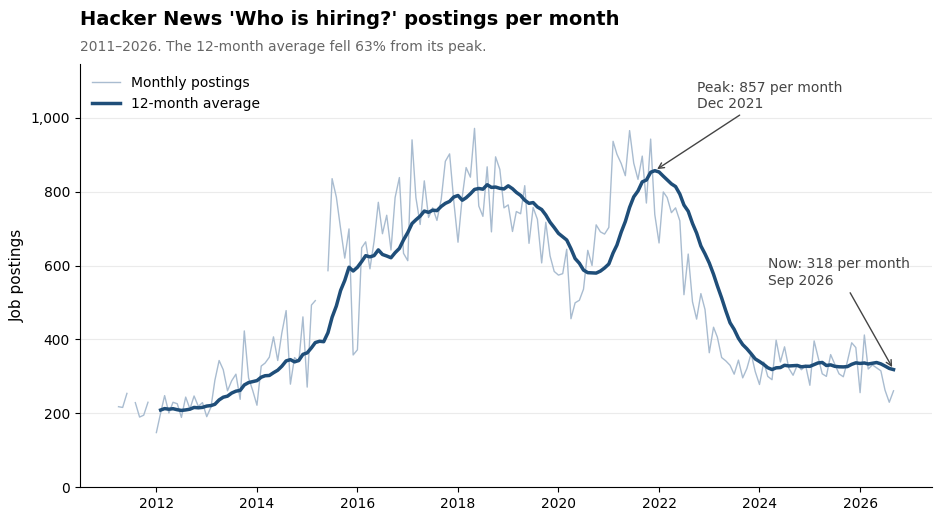

In [37]:
rolling_peak_month = rolling_average.idxmax()
rolling_peak_value = rolling_average.max()
latest_month = rolling_average.index.max()
latest_value = rolling_average.loc[latest_month]
decline_from_peak = 1 - (latest_value / rolling_peak_value)

figure, axis = plt.subplots()

axis.plot(
    monthly_counts.index,
    monthly_counts.values,
    color=MONTHLY_COLOR,
    linewidth=1,
    label="Monthly postings",
)
axis.plot(
    rolling_average.index,
    rolling_average.values,
    color=TREND_COLOR,
    linewidth=2.5,
    label="12-month average",
)

# Label positions are offsets from the points they describe, so they
# stay sensible if the data is refreshed with new months.
peak_label_position = (
    rolling_peak_month + pd.DateOffset(months=10),
    rolling_peak_value + 170,
)
axis.annotate(
    f"Peak: {rolling_peak_value:,.0f} per month\n{rolling_peak_month:%b %Y}",
    xy=(rolling_peak_month, rolling_peak_value),
    xytext=peak_label_position,
    color=ANNOTATION_COLOR,
    arrowprops={"arrowstyle": "->", "color": ANNOTATION_COLOR},
)

latest_label_position = (
    latest_month - pd.DateOffset(months=30),
    latest_value + 230,
)
axis.annotate(
    f"Now: {latest_value:,.0f} per month\n{latest_month:%b %Y}",
    xy=(latest_month, latest_value),
    xytext=latest_label_position,
    color=ANNOTATION_COLOR,
    arrowprops={"arrowstyle": "->", "color": ANNOTATION_COLOR},
)

axis.set_title(
    "Hacker News 'Who is hiring?' postings per month",
    loc="left",
    pad=28,
)
axis.text(
    0,
    1.03,
    f"2011–2026. The 12-month average fell {decline_from_peak:.0%} from its peak.",
    transform=axis.transAxes,
    color=SUBTITLE_COLOR,
)

axis.set_ylabel("Job postings")
axis.set_ylim(0, monthly_counts.max() * 1.18)
axis.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
axis.legend(loc="upper left", frameon=False)

figure.savefig(FIGURES_DIRECTORY / "01_monthly_volume.png", dpi=150, bbox_inches="tight")
plt.show()

In [38]:
annual_summary = postings.groupby("year").agg(
    postings=("comment_id", "count"),
    months_observed=("month_start", "nunique"),
)
annual_summary["postings_per_month"] = (
    annual_summary["postings"] / annual_summary["months_observed"]
)
annual_summary["change_vs_prior_year"] = annual_summary["postings_per_month"].pct_change()

print(annual_summary.round(3).to_string())

decline_from_peak = 1 - (latest_value / rolling_peak_value)
print(f"\n12-month average: {rolling_peak_value:,.0f}/month at peak "
      f"({rolling_peak_month:%b %Y}), {latest_value:,.0f}/month now "
      f"({latest_month:%b %Y}) — a {decline_from_peak:.0%} decline.")

      postings  months_observed  postings_per_month  change_vs_prior_year
year                                                                     
2011      1532                7             218.857                   NaN
2012      2594               12             216.167                -0.012
2013      3432               12             286.000                 0.323
2014      4315               12             359.583                 0.257
2015      5851               10             585.100                 0.627
2016      8030               12             669.167                 0.144
2017      9423               12             785.250                 0.173
2018      9686               12             807.167                 0.028
2019      8434               12             702.833                -0.129
2020      7120               12             593.333                -0.156
2021     10279               12             856.583                 0.444
2022      7578               12       

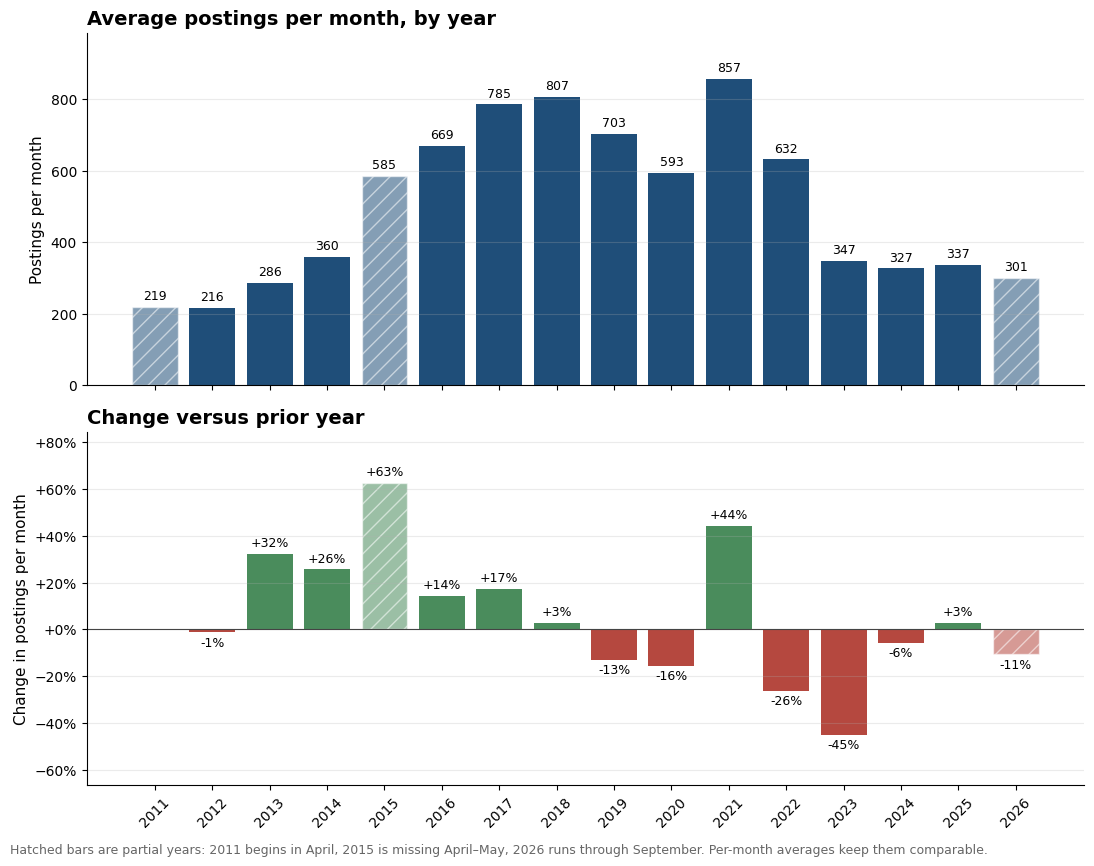

In [39]:
years = annual_summary.index.astype(int)
postings_per_month = annual_summary["postings_per_month"]
yearly_change_percent = annual_summary["change_vs_prior_year"] * 100
is_partial_year = annual_summary["months_observed"] < 12

figure, (volume_axis, change_axis) = plt.subplots(
    2,
    1,
    figsize=(11, 8.5),
    sharex=True,
)

# Top panel: average postings per month in each year.
volume_bars = volume_axis.bar(years, postings_per_month, color=TREND_COLOR)

for bar, partial in zip(volume_bars, is_partial_year):
    if partial:
        bar.set_alpha(0.55)
        bar.set_hatch("//")
        bar.set_edgecolor("white")

volume_labels = [f"{value:,.0f}" for value in postings_per_month]
volume_axis.bar_label(volume_bars, labels=volume_labels, padding=3, fontsize=9)

volume_axis.set_title("Average postings per month, by year", loc="left")
volume_axis.set_ylabel("Postings per month")
volume_axis.set_ylim(0, postings_per_month.max() * 1.15)
volume_axis.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

# Bottom panel: change versus the prior year. 2011 has no prior year.
has_prior_year = yearly_change_percent.notna()
change_years = years[has_prior_year]
change_values = yearly_change_percent[has_prior_year]
change_is_partial = is_partial_year[has_prior_year]

change_colors = []
for value in change_values:
    if value >= 0:
        change_colors.append(POSITIVE_COLOR)
    else:
        change_colors.append(NEGATIVE_COLOR)

change_bars = change_axis.bar(change_years, change_values, color=change_colors)

for bar, partial in zip(change_bars, change_is_partial):
    if partial:
        bar.set_alpha(0.55)
        bar.set_hatch("//")
        bar.set_edgecolor("white")

change_labels = [f"{value:+.0f}%" for value in change_values]
change_axis.bar_label(change_bars, labels=change_labels, padding=3, fontsize=9)

change_axis.axhline(0, color=ANNOTATION_COLOR, linewidth=0.8)
change_axis.set_title("Change versus prior year", loc="left")
change_axis.set_ylabel("Change in postings per month")
change_axis.yaxis.set_major_formatter(StrMethodFormatter("{x:+.0f}%"))
change_axis.margins(y=0.2)

change_axis.set_xticks(years)
change_axis.tick_params(axis="x", rotation=45)

figure.text(
    0.01,
    -0.01,
    "Hatched bars are partial years: 2011 begins in April, 2015 is missing April–May, "
    "2026 runs through September. Per-month averages keep them comparable.",
    color=SUBTITLE_COLOR,
    fontsize=9,
)

figure.tight_layout()
figure.savefig(FIGURES_DIRECTORY / "02_annual_volume.png", dpi=150, bbox_inches="tight")
plt.show()

### What the volume data shows

- **Peak and decline.** The 12-month average peaked at 857 postings per month
  in December 2021 and sits at 318 today, a 63% decline.
- **2023 was the sharpest year.** Postings per month fell 45%, the largest
  single-year drop in the dataset, a year after interest rates began rising.
- **The decline has stopped.** Since 2024 volume has held near 330 per month,
  roughly the 2014 level. The contraction was a step down to a new floor, not
  a continuing slide.
- **2021 was a rebound, not a summit.** It followed two declining years
  (2019–2020); the sustained high was the 2017–2018 plateau.
- **2026 is a partial year.** The January–September average is 301 per month,
  with a summer dip. Nine months is too short to call a renewed decline.

Posting counts measure how many companies chose to post on HN, which reflects
both hiring demand and the thread's popularity. They are best read as a relative
index of tech hiring, not an absolute count of jobs.

## 2. Which roles held up

Role analysis starts in 2017, the first year the pipe-delimited header
convention exceeded 90% adoption. Before that, roles are mostly unreadable
from headers and shares are artificially low.

Total volume fell sharply after 2021, so almost every role's raw count falls
too. To separate demand for a role from the overall contraction, roles are
shown two ways: indexed against the whole market, and as a share of postings.

Roles are grouped into families because titles drift over time; an
"ML Engineer" in 2017 and an "AI Engineer" in 2025 may be the same job.
Software engineering is omitted because its pattern includes the bare word
"engineer," which makes it a catch-all covering about half of all postings.

In [40]:
ROLE_START_YEAR = 2017

ROLE_FAMILIES_TO_CHART = {
    "role_ai_ml": "AI / ML",
    "role_data_science": "Data science",
    "role_infrastructure": "Infrastructure / DevOps",
    "role_mobile": "Mobile",
}

ROLE_COLORS = {
    "role_ai_ml": "#1f4e79",
    "role_data_science": "#c0504d",
    "role_infrastructure": "#6b8e3a",
    "role_mobile": "#8064a2",
}
ALL_POSTINGS_COLOR = "#999999"

role_window = postings[postings["year"] >= ROLE_START_YEAR]

role_yearly = pd.DataFrame({
    "months_observed": role_window.groupby("year")["month_start"].nunique(),
    "total_postings": role_window.groupby("year").size(),
})
role_yearly["total_per_month"] = (
    role_yearly["total_postings"] / role_yearly["months_observed"]
)

for column in ROLE_FAMILIES_TO_CHART:
    yearly_count = role_window.groupby("year")[column].sum()

    role_yearly[f"{column}_count"] = yearly_count
    role_yearly[f"{column}_per_month"] = yearly_count / role_yearly["months_observed"]
    role_yearly[f"{column}_share"] = yearly_count / role_yearly["total_postings"]

role_years = role_yearly.index.astype(int)

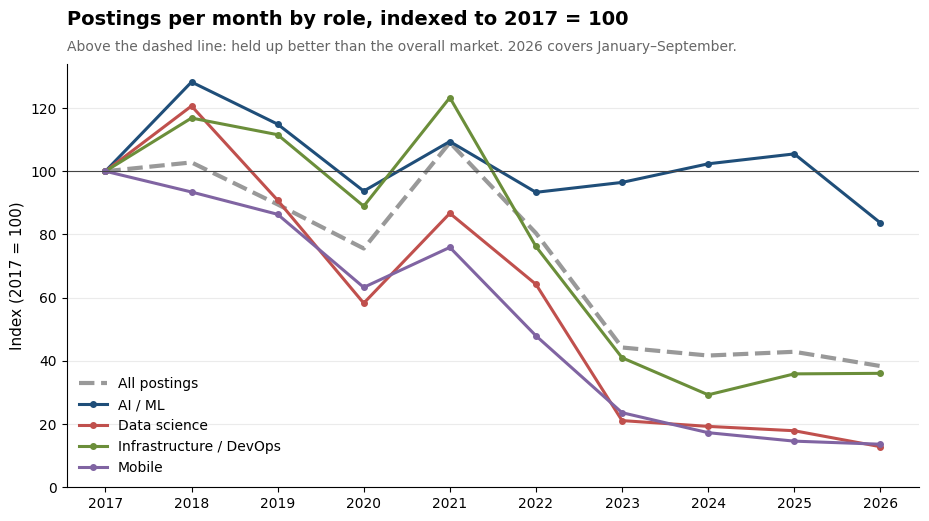

In [41]:
def index_to_base_year(series, base_year):
    """Rescale a series so its value in base_year equals 100."""
    return series / series.loc[base_year] * 100


figure, axis = plt.subplots()

all_postings_index = index_to_base_year(role_yearly["total_per_month"], ROLE_START_YEAR)
axis.plot(
    role_years,
    all_postings_index,
    color=ALL_POSTINGS_COLOR,
    linewidth=3,
    linestyle="--",
    label="All postings",
)

for column, label in ROLE_FAMILIES_TO_CHART.items():
    role_index = index_to_base_year(role_yearly[f"{column}_per_month"], ROLE_START_YEAR)

    axis.plot(
        role_years,
        role_index,
        color=ROLE_COLORS[column],
        linewidth=2.2,
        marker="o",
        markersize=4,
        label=label,
    )

axis.axhline(100, color=ANNOTATION_COLOR, linewidth=0.8)

axis.set_title(
    f"Postings per month by role, indexed to {ROLE_START_YEAR} = 100",
    loc="left",
    pad=28,
)
axis.text(
    0,
    1.03,
    "Above the dashed line: held up better than the overall market. "
    "2026 covers January–September.",
    transform=axis.transAxes,
    color=SUBTITLE_COLOR,
)

axis.set_ylabel(f"Index ({ROLE_START_YEAR} = 100)")
axis.set_ylim(bottom=0)
axis.set_xticks(role_years)
axis.legend(loc="lower left", frameon=False)

figure.savefig(FIGURES_DIRECTORY / "03_role_index.png", dpi=150, bbox_inches="tight")
plt.show()

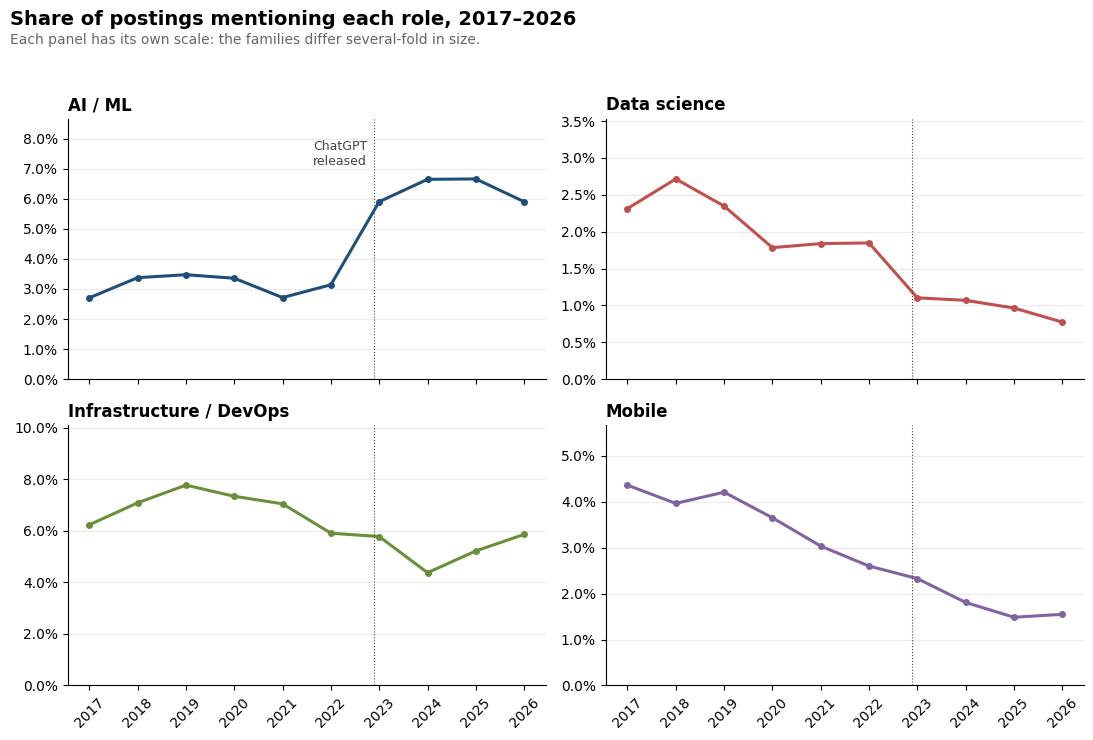

In [42]:
# The first thread after ChatGPT's release (November 30, 2022) was December 2022,
# so the marker sits just before the 2023 data point.
CHATGPT_MARKER_POSITION = 2022.9

figure, axes = plt.subplots(2, 2, figsize=(11, 7.5), sharex=True)

for axis, (column, label) in zip(axes.flatten(), ROLE_FAMILIES_TO_CHART.items()):
    share_percent = role_yearly[f"{column}_share"] * 100

    axis.plot(
        role_years,
        share_percent,
        color=ROLE_COLORS[column],
        linewidth=2.2,
        marker="o",
        markersize=4,
    )
    axis.axvline(CHATGPT_MARKER_POSITION, color=ANNOTATION_COLOR, linewidth=0.8, linestyle=":")

    axis.set_title(label, loc="left", fontsize=12)
    axis.set_ylim(0, share_percent.max() * 1.3)
    axis.yaxis.set_major_formatter(StrMethodFormatter("{x:.1f}%"))
    axis.set_xticks(role_years)
    axis.tick_params(axis="x", rotation=45)

first_axis = axes.flatten()[0]
first_axis.text(
    CHATGPT_MARKER_POSITION - 0.15,
    first_axis.get_ylim()[1] * 0.92,
    "ChatGPT\nreleased",
    ha="right",
    va="top",
    fontsize=9,
    color=ANNOTATION_COLOR,
)

figure.suptitle(
    f"Share of postings mentioning each role, {ROLE_START_YEAR}–2026",
    x=0.01,
    ha="left",
    fontsize=14,
    fontweight="bold",
)
figure.text(
    0.01,
    0.935,
    "Each panel has its own scale: the families differ several-fold in size.",
    color=SUBTITLE_COLOR,
)

figure.tight_layout(rect=(0, 0, 1, 0.93))
figure.savefig(FIGURES_DIRECTORY / "04_role_share.png", dpi=150, bbox_inches="tight")
plt.show()

In [43]:
role_summary = pd.DataFrame(index=role_yearly.index)
role_summary["all_per_month"] = role_yearly["total_per_month"].round(0)

for column, label in ROLE_FAMILIES_TO_CHART.items():
    short_name = column.replace("role_", "")
    role_summary[f"{short_name}_count"] = role_yearly[f"{column}_count"]
    role_summary[f"{short_name}_share"] = (role_yearly[f"{column}_share"] * 100).round(1)

print(role_summary.to_string())

      all_per_month  ai_ml_count  ai_ml_share  data_science_count  data_science_share  infrastructure_count  infrastructure_share  mobile_count  mobile_share
year                                                                                                                                                         
2017          785.0          255          2.7                 218                 2.3                   588                   6.2           411           4.4
2018          807.0          327          3.4                 263                 2.7                   687                   7.1           384           4.0
2019          703.0          293          3.5                 198                 2.3                   656                   7.8           355           4.2
2020          593.0          239          3.4                 127                 1.8                   523                   7.3           260           3.7
2021          857.0          279          2.7       

### What the role data shows

Figures use 2025 as the last full year; 2026 covers January–September.

- **AI/ML decoupled from the market in 2023.** From 2017 to 2022 AI/ML
  postings rose and fell with everything else. After ChatGPT's release they
  stopped falling: in 2025 AI/ML stood at 105% of its 2017 level while
  overall postings stood at 43%. The share of postings mentioning AI/ML
  roughly doubled, from about 3% to 6.7%, almost entirely because the rest
  of the market shrank around it.
- **Data science fell hardest, and fell in 2023.** It tracked the market
  through 2022, then dropped 67% in a single year while the market fell 45%.
  By 2025 data science postings were 18% of their 2017 level. The timing
  coincides with AI/ML's decoupling. This data cannot distinguish data
  science jobs disappearing from data science jobs being retitled; AI/ML
  postings became *less* likely to mention data science over this period,
  which rules out blended titles but not clean renaming.
- **Mobile's decline is structural.** Its share fell steadily from 4.4% to
  1.5% with no break at any market shock, consistent with a mature platform
  rather than a cyclical cut.
- **Infrastructure dipped and recovered.** It underperformed the market in
  2024, then recovered to 36% of its 2017 level by 2025 as its share climbed
  back toward 6%. Growth in AI compute is one possible driver, but this data
  does not test it.

Post-2023 data science counts are small (21–46 postings per year), so
year-to-year movements there are noisy. The overall magnitude of the decline
is far larger than that noise.